# Portefeuille par congressman — le copy-trading du Congrès bat-il le SPY ?

**But** : reconstruire le portefeuille de chaque membre (ses achats/ventes déclarés), le comparer au SPY,
classer les membres, tester si copier les meilleurs bat le marché.

**Méthode** :
- rendement *time-weighted* (un apport n'est jamais un rendement), pondération par l'argent (value-weight) ;
- univers **actions + ETF**, nettoyé en amont (S1/S2) ;
- entrée à la date de **transaction** (`traded`) = information parfaite → ce notebook mesure le
  **plafond théorique** ; la version jouable (entrée à la publication + coûts 20 bps) est le notebook 06 ;
- stratégie évaluée **brute** (sans coûts de transaction).

**Structure** :
- **Partie 1** — classement de tous les membres par **Information Ratio** (surperformance risque-ajustée vs SPY).
- **Partie 2** — éligibilité (≥ 10 trades, ≥ 126 jours) + **significativité** (test t unilatéral, $t > 1{,}645$).
- **Partie 2 bis** — le même classement **année par année** (walk-forward, sans regard vers le futur).
- **Partie 3** — **stratégie** de copie des top-4, évaluée **par année** vs le SPY.
- **Conclusion** — résultats et limites honnêtes.

# Partie 1 — Classement des membres par Information Ratio

## 0. Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/02_recherche_backtest"
PRICES = os.path.join(BASE, "cache", "prices_v2")

## 1. Charger les trades

- Source : la table **canonique** du nettoyage backtest S1/S2
  (`00_recuperation_donnees/data/clean/transactions_backtest_2014_2026.csv`, **134 464 lignes**) — la même que le 06.
- Tout le nettoyage transactionnel y est déjà fait (entonnoir A→D) : **on consomme, on ne re-filtre pas**.
- On renomme juste les colonnes pour la mécanique du 05 : `member_name→name`, `ticker_yahoo→ticker`,
  `direction→op`, `transaction_date→traded`, `amount_midpoint→size_usd`.

In [2]:
# Table PROPRE canonique S1/S2 (source-primaire, 134 464 x 36) -- la meme que le notebook 06.
# On aligne les noms de colonnes sur la mecanique du 05 : name / ticker / op / traded / size_usd.
# ticker <- ticker_yahoo (normalise Yahoo, matche le cache prices_v2) ; on drop le ticker brut.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_recuperation_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
df.shape   # attendu : (134464, 35)

(134464, 35)

## 2. Borner la fenêtre et projeter les colonnes

- L'univers (`op ∈ {buy, sell}`, ticker coté/normalisé, montant, dates) est **garanti en amont** — on ne re-nettoie rien.
- On restreint la fenêtre aux transactions **2013-2026** (exclut ~35 trades de 2012, hors périmètre).
- On projette les 6 colonnes utiles ; `size_usd` = **milieu de fourchette \$** (STOCK Act) = montant du lot.
- On mémorise les flags qualité amont (`is_delisted`, `flag_price_caution`) → réconciliation au §3.

In [3]:
n0 = len(df)
# Le nettoyage transactionnel est fait EN AMONT (nettoyage backtest S1/S2 : op in {buy,sell},
# ticker cote/normalise, secteur, montant, dates coherentes). On NE re-nettoie rien ici : on
# restreint la FENETRE d'etude a 2013-2026 (dates deja propres en amont) et on projette.
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)   # NaT -> annee NaN -> exclu
# flags qualite AMONT memorises AVANT projection (lecture robuste bool/texte) -> reconciliation en §3
_del = df["is_delisted"].astype(str).str.lower().isin(["true", "1"])
_cau = df["flag_price_caution"].astype(str).str.lower().isin(["true", "1"])
DELISTED_UP = set(df.loc[_del, "ticker"].dropna())          # tickers delistes signales en amont
CAUTION_UP  = set(df.loc[_cau, "ticker"].dropna())          # 'prudence join prix' (fusions/recyclage)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades (fenetre 2013-2026)  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")
print(f"flags qualite amont : {len(DELISTED_UP)} tickers delistes (is_delisted), {len(CAUTION_UP)} tickers 'prudence prix'")

134464 -> 134429 trades (fenetre 2013-2026)  |  372 membres  |  4618 tickers
flags qualite amont : 51 tickers delistes (is_delisted), 8 tickers 'prudence prix'


In [4]:
df.head()

,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5
3,F000462,Lois Frankel,STJ,buy,2014-12-03,8000.5
4,F000462,Lois Frankel,MMM,sell,2014-12-10,8000.5


## 3. Panel de prix (côté recherche) + SPY

- Le nettoyage S1/S2 est **purement transactionnel** : le panel de prix est la seule couche laissée à la
  recherche (le 06 fait pareil). Le SPY donne le **calendrier de bourse maître**.
- **Garde-fou anti-corruption Yahoo** : on exclut tout ticker dont le prix min $< 0{,}10$ \$ ou le saut
  journalier $> 300\,\%$ (prix négatifs, glitchs — ex. `DAIUF`). *Sans ce garde-fou, lors d'un run
  précédent, la stratégie affichait un excès factice de +12 %/an, entièrement dû au glitch `DAIUF` 2022.*
- Le flag amont `is_delisted` n'anticipe qu'une **petite fraction** de nos trous de prix (41/1 329 tickers
  écartés) : l'essentiel = symboles que Yahoo **ne sert plus** (délistés sans successeur).

In [5]:
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché
spy.tail(2)

Date
2026-07-01    745.760010
2026-07-02    744.780029
Name: close, dtype: float64

In [6]:
# 3.0 - Telecharge les prix ABSENTS du cache prices_v2 (resumable ; failed_v2.csv = echecs connus).
#        Cache complet => 0 telechargement => execution hors-ligne.
import yfinance as yf, time, logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)   # silence les warnings "possibly delisted"

os.makedirs(PRICES, exist_ok=True)
have0  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
fail_f = os.path.join(PRICES, "failed_v2.csv")             # meme liste de delistes que le notebook 06
failed = set(pd.read_csv(fail_f)["ticker"]) if os.path.exists(fail_f) else set()
todo   = [t for t in dict.fromkeys(df["ticker"]) if isinstance(t, str) and t not in have0 and t not in failed]
print(f"cache: {len(have0)} tickers | delistes/echecs connus sautes: {len(set(df['ticker']) & failed)} | a telecharger: {len(todo)}")

new_fail = []
for i in range(0, len(todo), 60):
    chunk = todo[i:i+60]
    try:
        data = yf.download(chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                           progress=False, threads=True, group_by="ticker")
    except Exception as e:
        print("  batch KO:", str(e)[:60]); data = None
    for t in chunk:
        s = None
        try:
            if data is not None and isinstance(data.columns, pd.MultiIndex):
                if t in data.columns.get_level_values(0):
                    s = data[t]["Close"].dropna()
            elif data is not None and "Close" in getattr(data, "columns", []):
                s = data["Close"].dropna()
        except Exception:
            s = None
        if s is None or len(s) < 20:
            new_fail.append(t)
        else:
            s.rename("close").to_csv(os.path.join(PRICES, t + ".csv"))   # en-tete Date,close
    time.sleep(0.4)

if new_fail:   # on complete failed_v2.csv dans son format 2-colonnes (ticker,classe)
    pd.DataFrame({"ticker": new_fail, "classe": "inattendu"}).to_csv(fail_f, mode="a", header=False, index=False)
print(f"telecharges OK: {len(todo) - len(new_fail)} | nouveaux echecs (delistes): {len(new_fail)}")

cache: 3351 tickers | delistes/echecs connus sautes: 1268 | a telecharger: 0
telecharges OK: 0 | nouveaux echecs (delistes): 0


In [7]:
# charger le prix de chaque ticker utile, aligné sur le calendrier maître
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)

prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()          # aligne + comble les petits trous

# garde-fou : exclure les series Yahoo CORROMPUES (prix negatif/quasi-nul, ou saut absurde >300%/jour)
corrompus = []
for tk in need:
    s = prices[tk].dropna()
    if len(s) < 2 or s.min() < 0.10 or s.pct_change().abs().max() > 3.0:
        corrompus.append(tk)
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]

n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)}  |  sans prix : {len(missing)}  |  corrompus exclus : {len(corrompus)}  |  trades jetes : {n_drop}")
# delegation visible : les flags AMONT anticipent-ils nos trous de prix ?
ecartes = set(missing) | set(corrompus)
print(f"  -> deja signales en amont : {len(ecartes & DELISTED_UP)}/{len(ecartes)} tickers ecartes sont 'is_delisted' (nettoyage S1/S2)")

tickers avec prix : 3289  |  sans prix : 1268  |  corrompus exclus : 61  |  trades jetes : 16400
  -> deja signales en amont : 41/1329 tickers ecartes sont 'is_delisted' (nettoyage S1/S2)


## 4. Parts détenues chaque jour — `member_shares`

Pour un membre, les étapes 1→3 du plan :
1. **chaque achat → des parts** : $\text{parts} = \dfrac{\text{montant}}{P_i(\text{1er jour} \ge \texttt{traded})}$ ;
2. **chaque vente → retire des parts**, short interdit :
   $\text{parts vendues} = \min\!\big(\text{montant}/P_i,\ \text{parts détenues}\big)$
   — le $\min$ règle le cas « vente sans achat connu » ;
3. **détentions cumulées** : $n_i(t) = \sum_{\text{achats} \le t} \text{parts} \;-\; \sum_{\text{ventes} \le t} \text{parts}$
   → le tableau $N$, une colonne par ticker.

In [8]:
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marche)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

In [9]:
def member_shares(g):
    # g = trades d'un membre  ->  N (parts detenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

**Démo** sur un membre. À changer via `MEMBRE`.

In [10]:
MEMBRE = "John Fetterman"
g = df[df["name"] == MEMBRE]
Nm = member_shares(g)
g[["ticker", "op", "traded", "size_usd"]]

,ticker,op,traded,size_usd
112305,GOOG,buy,2025-05-15,8000.5
112306,JPM,buy,2025-06-17,8000.5
117848,ERIE,buy,2026-03-27,8000.5
117849,MSFT,buy,2026-03-27,8000.5
117850,T,sell,2026-03-27,8000.5
117851,MSFT,buy,2026-03-30,8000.5
117852,AMZN,buy,2026-03-30,8000.5
117853,GOOG,buy,2026-03-30,8000.5
117854,ERIE,buy,2026-03-30,8000.5
117855,MU,buy,2026-03-30,8000.5


Le tableau `N` : parts détenues par jour. Monte à l'achat, baisse à la vente.

In [11]:
actifs = Nm[Nm.sum(axis=1) > 0]
actifs.iloc[::max(1, len(actifs) // 12)].round(1)      # apercu

,AMZN,ERIE,GOOG,JPM,MSFT,MU,T
Date,,,,,,,
2025-05-15,0.0,0.0,48.6,0.0,0.0,0.0,0.0
2025-06-18,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2025-07-23,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2025-08-25,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2025-09-26,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2025-10-29,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2025-12-02,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2026-01-06,0.0,0.0,48.6,30.3,0.0,0.0,0.0
2026-02-09,0.0,0.0,48.6,30.3,0.0,0.0,0.0


## 5. Rendement quotidien — `daily_return`

- Étape 4 — valeur du portefeuille chaque jour : $V(t) = \sum_i n_i(t)\,P_i(t)$.
- Étape 5 — rendement du jour, **sans mélanger le portefeuille avec les achats/ventes du jour**
  (on valorise les parts de la **veille**) :
$$r_P(t) \;=\; \frac{\sum_i n_i(t-1)\,P_i(t)}{\sum_i n_i(t-1)\,P_i(t-1)} \;-\; 1$$
  → un apport n'est jamais un rendement (*time-weighted*).
- Étape 6 — jour sans position : $r_P(t) = 0$ (cash). Système **ouvert** : pas de cash suivi,
  le produit d'une vente n'est pas réinjecté ailleurs.
- Garde-fou : $r_P$ winsorisé à $\pm 50\,\%$/jour (`clip`) — neutralise tout glitch Yahoo résiduel.

In [12]:
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Sum n_i(t-1) * P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Sum n_i(t-1) * P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # FIX : garde-fou +/-50%/jour (winsorisation)
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]   # 1re -> derniere position

In [13]:
rm = daily_return(Nm)
rm.describe()

count    284.000000
mean       0.002414
std        0.013197
min       -0.035827
25%       -0.005914
50%        0.001563
75%        0.011263
max        0.047893
dtype: float64

## 6. Stats d'un portefeuille — `stats`

Étape 7 — les courbes et stats du membre, $E$ et $\sigma$ depuis le début (2014-2026) :
$$\mathrm{NAV}(t) = \prod_{s \le t}\big(1 + r_P(s)\big) \qquad
\mathrm{CAGR} = \mathrm{NAV}_T^{\,252/T} - 1 \qquad
\mathrm{vol} = \sigma(r_P)\sqrt{252} \qquad
\mathrm{Sharpe} = \frac{E(r_P)}{\sigma(r_P)}\sqrt{252} \qquad \mathrm{maxDD}$$

In [14]:
def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr,
                vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [15]:
stats(rm)

{'cagr': np.float64(0.7965022756820705),
 'vol': np.float64(0.20950040205925885),
 'sharpe': np.float64(2.9035504663310174),
 'maxdd': np.float64(-0.16161189234891238)}

### Visuel : le portefeuille du membre vs le SPY (base 100)

Étape 8 — la même courbe pour le marché : $r_{SPY}(t) = \dfrac{SPY(t)}{SPY(t-1)} - 1$
→ $\mathrm{NAV}_{SPY}$, $\mathrm{vol}_{SPY}$, $\mathrm{Sharpe}_{SPY}$.

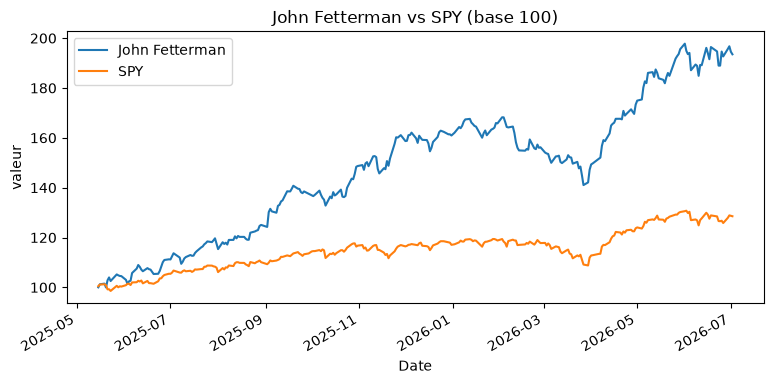

In [16]:
nav_m = (1 + rm).cumprod()
nav_s = (1 + r_spy.reindex(rm.index).fillna(0)).cumprod()
ax = (100 * nav_m).plot(label=MEMBRE, figsize=(9, 4))
(100 * nav_s).plot(ax=ax, label="SPY")
ax.set_title(f"{MEMBRE} vs SPY (base 100)"); ax.set_ylabel("valeur"); ax.legend(); plt.show()

## 7. Battre le SPY — l'Information Ratio

Étape 9 — la série d'**excès** (rendement du track $-$ rendement du SPY) :
$$x(t) = r_P(t) - r_{SPY}(t) \qquad
\mathrm{IR} = \frac{\bar x}{\sigma(x)}\sqrt{252} \;\;(= \mathrm{Sharpe}_x)$$
- $\mathrm{IR} > 0$ → il bat le SPY ; plus c'est grand, plus l'avance est **régulière**.
- **C'est le critère : on classe.**

In [17]:
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

In [18]:
info_ratio(rm)

np.float64(2.4823873484087646)

## 8. Classer TOUS les membres par IR
Une ligne par membre, triée par IR décroissant.

In [19]:
rows = []
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    s = stats(r)
    rows.append(dict(name=g["name"].iloc[0], n_trades=len(g), n_days=len(r),
                     IR=info_ratio(r), sharpe=s["sharpe"],
                     cagr=s["cagr"], vol=s["vol"], maxdd=s["maxdd"]))

tab = pd.DataFrame(rows).sort_values("IR", ascending=False).reset_index(drop=True)
print(len(tab), "membres classes")

266 membres classes


### Top 20

In [20]:
tab.head(20).round(3)

,name,n_trades,n_days,IR,sharpe,cagr,vol,maxdd
0,John Fetterman,10,284,2.482,2.904,0.797,0.210,-0.162
1,Ashley Moody,23,364,1.670,1.660,0.863,0.431,-0.339
2,Greg Steube,1,74,1.623,1.874,3.133,1.030,-0.318
3,Morgan McGarvey,24,853,1.502,1.714,0.611,0.306,-0.284
4,Lisa McClain,1479,580,1.264,1.427,0.601,0.380,-0.317
5,Bruce Westerman,208,336,1.194,1.579,0.339,0.197,-0.163
6,Terri A. Sewell,4,308,1.160,1.899,0.560,0.251,-0.152
7,Kim Schrier,40,165,1.106,0.867,0.208,0.255,-0.171
8,Daniel S Sullivan,100,904,0.999,1.333,0.416,0.293,-0.287
9,Thomas Suozzi,662,2230,0.902,0.993,0.237,0.245,-0.405


### Visuel : top 20 par IR

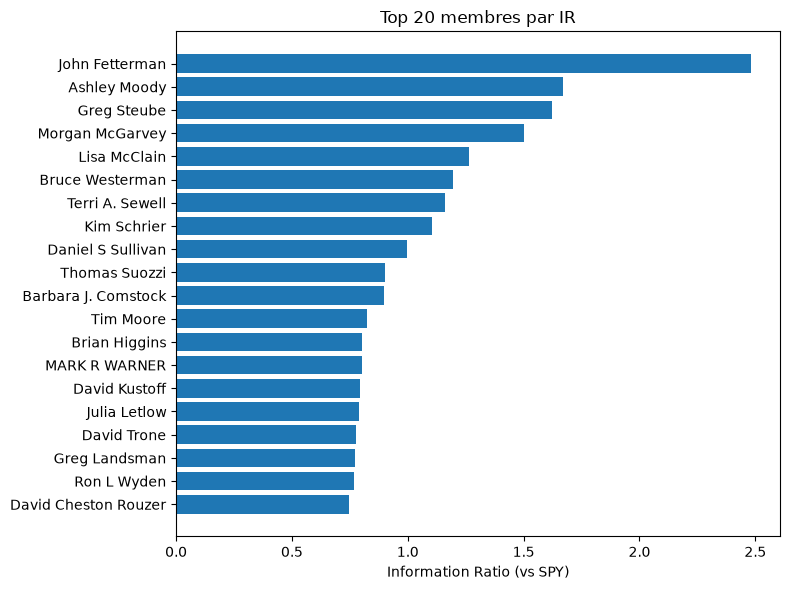

In [21]:
top = tab.head(20).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["name"], top["IR"])
plt.xlabel("Information Ratio (vs SPY)")
plt.title("Top 20 membres par IR")
plt.tight_layout(); plt.show()

**Fin de Partie 1** — 266 membres classés par IR. Mais un IR calculé sur 3 trades et 2 mois ne veut
rien dire : il faut filtrer (éligibilité) puis tester (significativité) → Partie 2.

# Partie 2 — Éligibilité + significativité

Le classement brut est **pollué** par des membres à 1 trade (hasard). On fait dans l'ordre :
1. **B.1 — éligibilité** : garder les membres qui ont assez de matière ;
2. **B.2 — significativité** : sur ces éligibles, tester si l'IR est du talent ou de la chance.

## B.1 — Éligibilité : ≥ 10 trades et ≥ 126 jours

Un IR sur 1 trade / 20 jours n'a aucun sens (comme « gagner 1 lancer de pièce »).
- `n_trades ≥ 10` : plusieurs décisions pour juger un style.
- `n_days ≥ 126` (~6 mois) : sinon le ratio est instable.

La table de la Partie 1 contient déjà tout (`IR`, `n_trades`, `n_days`) — on la reprend telle quelle.

In [22]:
rank = tab.copy()
print(len(rank), "membres")

266 membres


On filtre les éligibles et on re-trie par IR.

In [23]:
MIN_TRADES, MIN_DAYS = 10, 126
elig = (rank[(rank.n_trades >= MIN_TRADES) & (rank.n_days >= MIN_DAYS)]
        .sort_values("IR", ascending=False).reset_index(drop=True))
print(f"{len(rank)} -> {len(elig)} membres eligibles")
elig.head(10).round(3)

266 -> 223 membres eligibles


,name,n_trades,n_days,IR,sharpe,cagr,vol,maxdd
0,John Fetterman,10,284,2.482,2.904,0.797,0.210,-0.162
1,Ashley Moody,23,364,1.670,1.660,0.863,0.431,-0.339
2,Morgan McGarvey,24,853,1.502,1.714,0.611,0.306,-0.284
3,Lisa McClain,1479,580,1.264,1.427,0.601,0.380,-0.317
4,Bruce Westerman,208,336,1.194,1.579,0.339,0.197,-0.163
5,Kim Schrier,40,165,1.106,0.867,0.208,0.255,-0.171
6,Daniel S Sullivan,100,904,0.999,1.333,0.416,0.293,-0.287
7,Thomas Suozzi,662,2230,0.902,0.993,0.237,0.245,-0.405
8,Barbara J. Comstock,85,2390,0.899,1.070,0.262,0.246,-0.332
9,Tim Moore,163,374,0.822,1.235,0.354,0.276,-0.173


### Qui sort du top brut ? (les petits échantillons chanceux)

In [24]:
raw_top = rank.sort_values("IR", ascending=False).head(10)
removed = raw_top[(raw_top.n_trades < MIN_TRADES) | (raw_top.n_days < MIN_DAYS)]
removed[["name", "n_trades", "n_days", "IR"]].round(2)

,name,n_trades,n_days,IR
2,Greg Steube,1,74,1.62
6,Terri A. Sewell,4,308,1.16


### Visuel : les IR extrêmes sont sur les petits échantillons

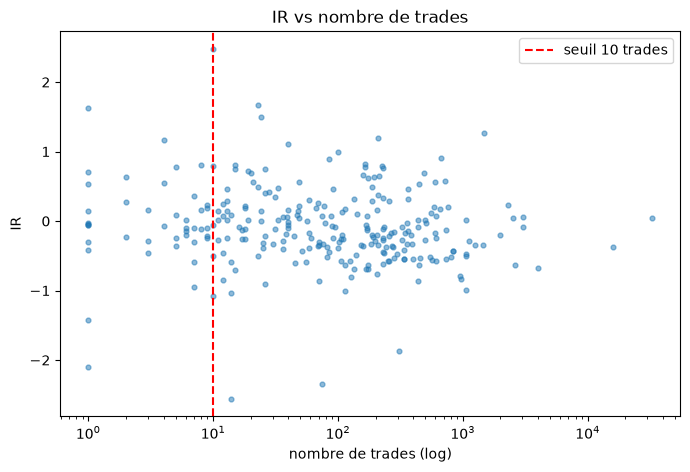

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(rank.n_trades, rank.IR, s=12, alpha=0.5)
plt.axvline(MIN_TRADES, color="red", ls="--", label=f"seuil {MIN_TRADES} trades")
plt.xscale("log"); plt.xlabel("nombre de trades (log)"); plt.ylabel("IR")
plt.title("IR vs nombre de trades"); plt.legend(); plt.show()

## B.2 — Significativité : talent ou accident ?

- Test $t$ sur la moyenne de l'excès quotidien $x(t) = r_P(t) - r_{SPY}(t)$ :
$$t = \frac{\bar x}{\sigma(x)/\sqrt{n}} = \mathrm{IR}\cdot\sqrt{n_{\text{jours}}/252}$$
- Question **unilatérale** (« bat-il le SPY ? ») → queue droite seulement : seuil 5 % $t > 1{,}645$.
- Conséquence : un bon IR sur peu d'années ne suffit pas — il faut la durée.

On calcule `t` pour chaque membre éligible et on compte ceux qui battent le SPY (`t > 1,645`).

In [26]:
elig["t"] = elig.IR * np.sqrt(elig.n_days / 252)
sig = elig[elig.t > 1.645]
print(f"{len(sig)} / {len(elig)} membres eligibles avec t > 1,645 (bat le SPY, unilateral 5%)")
elig.sort_values("t", ascending=False).head(20)[["name", "n_trades", "n_days", "IR", "t"]].round(2)

20 / 223 membres eligibles avec t > 1,645 (bat le SPY, unilateral 5%)


,name,n_trades,n_days,IR,t
8,Barbara J. Comstock,85,2390,0.90,2.77
2,Morgan McGarvey,24,853,1.50,2.76
7,Thomas Suozzi,662,2230,0.90,2.68
0,John Fetterman,10,284,2.48,2.64
20,Suzan K. DelBene,157,3054,0.66,2.30
17,Brenda Lulenar Lawrence,19,2430,0.72,2.24
10,MARK R WARNER,15,1934,0.80,2.22
18,Brian Babin,20,2573,0.69,2.21
15,David Cheston Rouzer,26,2106,0.75,2.15
24,Sheldon Whitehouse,718,3316,0.57,2.07


### Visuel : distribution des t (par membre éligible)

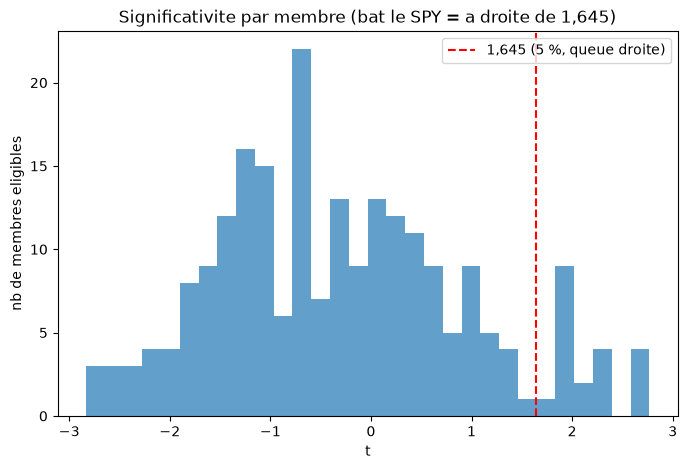

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(elig.t.dropna(), bins=30, alpha=0.7)
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t"); plt.ylabel("nb de membres eligibles")
plt.title("Significativite par membre (bat le SPY = a droite de 1,645)"); plt.legend(); plt.show()

### Le classement final : les significatifs, triés par IR

- On garde les membres à $t > 1{,}645$, classés par **IR décroissant** — le classement retenu de la Partie 2.
- ⚠️ **Tests multiples** : on teste 223 membres → $223 \times 5\,\% \approx 11$ « significatifs » attendus
  **par pur hasard**. On en trouve **20** (~1,8:1) : léger surnombre, **pas une preuve forte** — une
  correction de Bonferroni durcirait le seuil ($t \gtrsim 3{,}5$), non appliquée ici.

In [28]:
# Les membres SIGNIFICATIFS (t > 1,645), classes par IR decroissant
sig_par_ir = sig.sort_values("IR", ascending=False).reset_index(drop=True)
print(f"{len(sig_par_ir)} membres significatifs, classes par IR")
sig_par_ir[["name", "n_trades", "n_days", "IR", "t"]].round(3)

20 membres significatifs, classes par IR


,name,n_trades,n_days,IR,t
0,John Fetterman,10,284,2.482,2.635
1,Ashley Moody,23,364,1.670,2.007
2,Morgan McGarvey,24,853,1.502,2.764
3,Lisa McClain,1479,580,1.264,1.917
4,Daniel S Sullivan,100,904,0.999,1.892
5,Thomas Suozzi,662,2230,0.902,2.683
6,Barbara J. Comstock,85,2390,0.899,2.769
7,MARK R WARNER,15,1934,0.800,2.218
8,David Kustoff,10,1595,0.793,1.994
9,Ron L Wyden,231,1568,0.770,1.920


**Fin de Partie 2** — 223 éligibles, **20 significatifs** (vs ~11 attendus par hasard). Mais tout est
calculé sur la fenêtre **complète** 2014-2026 : ce classement « regarde le futur » → Partie 2 bis.

# Partie 2 bis — Le même classement, année après année (walk-forward)

- Le classement de la Partie 2 utilise **toute** la fenêtre 2014-2026 : il regarde le futur.
- On refait **exactement le même classement** (éligibilité, significativité $t > 1{,}645$, tri par IR) à
  des **dates de coupe** croissantes : fin 2014, fin 2015, …, fin 2026.
- À chaque coupe fin-$Y$ : seulement les rendements et trades **connus au 31/12/$Y$**
  (`r.loc[:Y-12-31]`, `traded ≤ Y-12-31`) — **aucun regard vers le futur**.
- Contrôle : la dernière fenêtre (2014-2026) doit reproduire le classement final de la Partie 2.

In [29]:
# On prepare une fois la serie de rendement complete + les dates de trade par membre.
# member_shares/daily_return sont CUMULATIFS : les parts au jour t ne dependent que des trades <= t.
# => tronquer r a une date de coupe (r.loc[:yend]) ne fait JAMAIS regarder le futur.
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une serie de rendement")

266 membres avec une serie de rendement


In [30]:
def classement_a_fin(Y, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645):
    """Le classement de la Partie 2 (eligibilite + significativite + tri par IR),
    mais avec la SEULE info connue au 31/12/Y (point-in-time, aucun regard vers le futur)."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:yend]                                   # rendements connus a la coupe
        n_trades = int((wf_traded[bid] <= yend).sum())      # trades connus a la coupe
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0:
            continue
        if n_trades < min_trades or n_days < min_days:      # eligibilite (point-in-time)
            continue
        x = (rr - r_spy.reindex(rr.index)).dropna()
        if len(x) < 2 or x.std() == 0:
            continue
        ir = x.mean() / x.std() * np.sqrt(252)              # IR sur le passe
        t = ir * np.sqrt(n_days / 252)                      # significativite unilaterale
        if t <= seuil_t:                                    # ne garder que les significatifs
            continue
        rows.append(dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=n_trades, n_days=n_days, IR=ir, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "IR", "t"]
    return (pd.DataFrame(rows).sort_values("IR", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

In [31]:
# Une fenetre grandissante par annee : 2014, 2014-2015, ..., 2014-2026
ANNEES = range(2014, 2027)
clsmt = {Y: classement_a_fin(Y) for Y in ANNEES}

# Resume : combien de significatifs et le trio de tete (par IR) a chaque coupe
resume = pd.DataFrame([
    dict(fenetre=f"2014-{Y}",
         n_significatifs=len(clsmt[Y]),
         top1=clsmt[Y].name.iloc[0] if len(clsmt[Y]) > 0 else "-",
         top2=clsmt[Y].name.iloc[1] if len(clsmt[Y]) > 1 else "-",
         top3=clsmt[Y].name.iloc[2] if len(clsmt[Y]) > 2 else "-")
    for Y in ANNEES])
resume

,fenetre,n_significatifs,top1,top2,top3
0,2014-2014,1,John F Reed,-,-
1,2014-2015,4,David B. McKinley,Susan A. Davis,Michael G. Fitzpatrick
2,2014-2016,2,Billy Long,"Angus S King, Jr.",-
3,2014-2017,4,Barbara J. Comstock,Billy Long,"Angus S King, Jr."
4,2014-2018,5,Denny Heck,Dwight Evans,"Angus S King, Jr."
5,2014-2019,8,Dwight Evans,Denny Heck,Barbara J. Comstock
6,2014-2020,19,Donald Sternoff Beyer,Gilbert Cisneros,Barbara J. Comstock
7,2014-2021,13,Barbara J. Comstock,MARK R WARNER,Denny Heck
8,2014-2022,7,Suzan K. DelBene,Barbara J. Comstock,Austin Scott
9,2014-2023,12,Greg Landsman,Daniel S Sullivan,Barbara J. Comstock


In [32]:
# Une fenetre en exemple : la derniere (2014-2026) doit reproduire le classement final de la Partie 2.
# (changer Y pour inspecter une autre coupe)
Y = 2026
print(f"=== fenetre 2014-{Y}  |  {len(clsmt[Y])} membre(s) significatif(s), classe(s) par IR ===")
print(clsmt[Y].round(2).to_string(index=False))

=== fenetre 2014-2026  |  20 membre(s) significatif(s), classe(s) par IR ===
bioguide_id                    name  n_trades  n_days   IR    t
    F000479          John Fetterman        10     284 2.48 2.64
    M001244            Ashley Moody        23     364 1.67 2.01
    M001220         Morgan McGarvey        24     853 1.50 2.76
    M001136            Lisa McClain      1479     580 1.26 1.92
    S001198       Daniel S Sullivan       100     904 1.00 1.89
    S001201           Thomas Suozzi       662    2230 0.90 2.68
    C001105     Barbara J. Comstock        85    2390 0.90 2.77
    W000805           MARK R WARNER        15    1934 0.80 2.22
    K000392           David Kustoff        10    1595 0.79 1.99
    W000779             Ron L Wyden       231    1568 0.77 1.92
    R000603    David Cheston Rouzer        26    2106 0.75 2.15
    L000581 Brenda Lulenar Lawrence        19    2430 0.72 2.24
    B001291             Brian Babin        20    2573 0.69 2.21
    D000617        Suzan K.

### Ce que le walk-forward révèle (et que le plein-échantillon cache)

- **La liste grossit avec l'historique, en tendance** : 1 significatif fin 2014 → 4 (2015) → 8 (2019) →
  19-20 (2020, 2025-2026), avec des creux (2 en 2016, 7 en 2022) — plus de données, plus de membres
  franchissent le seuil.
- **Le n°1 change presque chaque année** : Reed (2014) → McKinley (2015) → Long (2016) → Comstock (2017)
  → Heck (2018) → Evans (2019) → Beyer (2020) → Comstock (2021) → DelBene (2022) → Landsman (2023) →
  McGarvey (2024-2025) → Fetterman (2026). **Le meilleur d'aujourd'hui n'est presque jamais celui d'hier.**
- **Quelques noms robustes** : **Suzan DelBene** est significative à *chaque* fenêtre depuis 2018,
  **Barbara Comstock** à toutes sauf une depuis 2017 — eux résistent au walk-forward, pas les têtes de
  classement.
- **Le plein-échantillon trompe** : John Fetterman est n°1 sur 2014-2026 (IR 2,48… sur 284 jours) mais
  n'apparaît qu'à la **toute dernière** fenêtre — on ne l'aurait jamais suivi « en direct ». Idem Ashley
  Moody (n°2, 364 jours).
- **Contrôle de cohérence** : la fenêtre 2014-2026 reproduit le classement final de la Partie 2 ; la
  sélection fin-2019 est exactement celle que la Partie 3 utilisera (`select_topK`).

# Partie 3 — Stratégie Ramify (walk-forward, top-4)

**Copy trading.** Chaque année, on suit les **4 meilleurs** congressmen (par IR **sur le passé**), et on tient leur panier l'année suivante.

**On met la stratégie en place sur 1 an, puis on re-choisit.** Donc on **évalue PAR ANNÉE** : chaque année = une observation (l'excès de la stratégie sur le SPY cette année-là).

**2 façons de combiner les 4 membres** : (A) `1/K` (chacun égal) · (B) `IR` (les meilleurs pèsent plus).

## On réutilise le rendement calculé en Partie 2 bis

La Partie 3 s'appuie directement sur la Partie 2 bis : `wf_ret` (rendement quotidien par membre) et
`classement_a_fin(Y)` (éligibilité + significativité + tri par IR, point-in-time). Rien à recalculer.

## Sélection walk-forward : on réutilise le classement de la Partie 2 bis

`select_topK(Y, K)` prend simplement les **K premiers** de `classement_a_fin(Y)` — c'est-à-dire les membres
**éligibles + significatifs** (`t > 1,645`), triés par **IR**, calculés **sur ≤ 31/12/Y**. Repli : moins de K si peu de significatifs.

In [33]:
# La selection de la Partie 3 REUTILISE le classement walk-forward de la Partie 2 bis (une seule source de verite).
def select_topK(Y, K):
    c = classement_a_fin(Y)          # eligibilite + significativite (t>1,645) + tri par IR, point-in-time (<=31/12/Y)
    return list(zip(c["IR"].head(K), c["bioguide_id"].head(K)))   # [(IR, bid), ...]  (peut etre < K -> repli)

**Démo** : qui suivrait-on en 2020 (sélection fin 2019) et leur IR ?

In [34]:
[(round(ir, 2), df[df.bioguide_id == b].name.iloc[0]) for ir, b in select_topK(2019, 4)]

[(1.46, 'Dwight Evans'),
 (1.42, 'Denny Heck'),
 (1.28, 'Barbara J. Comstock'),
 (1.18, 'Thomas Suozzi')]

### Combien de significatifs par année ? (repli si < 4)

In [35]:
# select_topK recalcule classement_a_fin : l'assert garantit le determinisme du recalcul
nb_sig = {Y: len(select_topK(Y, 999)) for Y in range(2015, 2026)}
assert all(nb_sig[Y] == len(clsmt[Y]) for Y in nb_sig)
pd.Series(nb_sig, name="nb_significatifs")

2015     4
2016     2
2017     4
2018     5
2019     8
2020    19
2021    13
2022     7
2023    12
2024    17
2025    20
Name: nb_significatifs, dtype: int64

## Les 2 façons de combiner les $K = 4$ membres

$$\text{(A) équipondéré : } w_k = \frac{1}{K} \qquad\qquad
\text{(B) pondéré IR : } w_k = \frac{\mathrm{IR}_k}{\sum_j \mathrm{IR}_j}$$
$$r_{\text{strat}}(t) = \sum_k w_k \, r_{m,k}(t)$$

In [36]:
def run_strategy(K, mode, years=range(2015, 2026)):
    parts = []
    for Y in years:
        sel = select_topK(Y, K)
        if not sel:
            continue
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:                                              # "ir"
            irs = np.array([ir for ir, _ in sel])
            w = irs / irs.sum() if irs.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[cal.year == (Y + 1)]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        parts.append((R * w).sum(axis=1))
    return pd.concat(parts).sort_index()

## Évaluation PAR ANNÉE

- Chaque année $Y{+}1$ = **une observation**, l'excès composé de l'année :
$$x_{\text{strat},\,Y} = \prod_{t \in Y}\big(1+r_{\text{strat}}(t)\big) - \prod_{t \in Y}\big(1+r_{SPY}(t)\big)$$
- $\mathrm{IR}_{\text{annuel}} = \dfrac{\bar x_{\text{strat}}}{\sigma(x_{\text{strat}})}$
  (l'Information Ratio de l'excès, à l'échelle annuelle), puis $t = \mathrm{IR}_{\text{annuel}}\cdot\sqrt{n}$.
- On suit les sélections fin-2015 → fin-2025, soit $n = 11$ années évaluées (2016-2026) ;
  seuil unilatéral 5 % : $t_{10} \approx 1{,}81$.

In [37]:
def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    out = {}
    for y in sorted(set(r.index.year)):
        m = r.index.year == y
        out[y] = ((1 + r[m]).prod() - 1) - ((1 + b[m]).prod() - 1)   # exces de l'annee
    return pd.Series(out)

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

eval_tab = pd.DataFrame({"1/K": eval_yearly(run_strategy(4, "equal")),
                         "IR":  eval_yearly(run_strategy(4, "ir"))}).T
eval_tab.index.name = "schema"
eval_tab.round(3)

,exces_moyen,IR_annuel,t,gagnantes
schema,,,,
1/K,0.036491,0.344214,1.141628,7/11
IR,0.035121,0.327474,1.086108,7/11


In [38]:
# Une annee en exemple : la selection fin-2019 (demo plus haut) tenue en 2020
ex = yearly_excess(run_strategy(4, "equal"))
print(f"2020 (selection fin-2019 : Evans, Heck, Comstock, Suozzi) : exces {ex[2020]:+.1%} vs SPY")

2020 (selection fin-2019 : Evans, Heck, Comstock, Suozzi) : exces +16.0% vs SPY


### Visuel : l'excès année par année (est-il régulier, ou porté par une seule année ?)

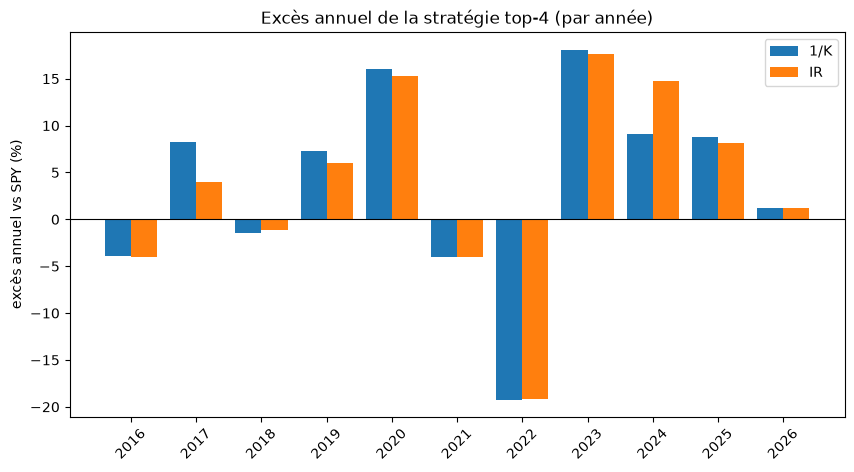

In [39]:
ex_eq = yearly_excess(run_strategy(4, "equal"))
ex_ir = yearly_excess(run_strategy(4, "ir"))
x = np.arange(len(ex_eq))
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, ex_eq.values * 100, 0.4, label="1/K")
plt.bar(x + 0.2, ex_ir.values * 100, 0.4, label="IR")
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, ex_eq.index, rotation=45); plt.ylabel("excès annuel vs SPY (%)")
plt.title("Excès annuel de la stratégie top-4 (par année)"); plt.legend(); plt.show()

### Composition : quelles actions détient le portefeuille combiné ? (exemple mi-2020, schéma IR)

In [40]:
def composition(Y, K, mode, asof):
    sel = select_topK(Y, K)
    if mode == "equal":
        mw = {b: 1 / len(sel) for _, b in sel}
    else:
        irs = np.array([ir for ir, _ in sel]); s = irs.sum()
        mw = {b: (ir / s if s > 0 else 1 / len(sel)) for ir, b in sel}
    total = {}
    for _, b in sel:
        N = member_shares(df[df.bioguide_id == b])
        if N is None:
            continue
        sub = N.loc[:asof]
        if len(sub) == 0:
            continue
        row = sub.iloc[-1]
        val = {tk: row[tk] * prices[tk].loc[:asof].iloc[-1] for tk in N.columns if row[tk] > 0}
        tot = sum(val.values())
        if tot <= 0:
            continue
        for tk, v in val.items():
            total[tk] = total.get(tk, 0.0) + mw[b] * (v / tot)     # poids melange
    comp = pd.Series(total).sort_values(ascending=False)
    return (comp / comp.sum() * 100).round(1)

composition(2019, 4, "ir", pd.Timestamp("2020-06-30")).head(10)

MSFT     14.3
AAPL     12.3
GOOGL     7.0
AMZN      5.2
GOOG      5.2
PCAR      4.9
MDT       4.6
TDG       3.6
NKE       1.8
NFLX      1.6
dtype: float64

# Conclusion

## Ce qu'on a trouvé

**Classement des membres (Parties 1-2, 2014-2026)** :
- **266 membres** avec un historique, **223 éligibles** (≥ 10 trades, ≥ 126 jours),
  **20 significatifs** ($t > 1{,}645$) — vs ~11 attendus par hasard sur 223 tests ;
- en **walk-forward** (Partie 2 bis), la tête du classement change presque chaque année ; seules quelques
  régulières résistent (**Suzan DelBene**, **Barbara Comstock**).

**Stratégie top-4 (Partie 3), évaluée par année (2016-2026, $n = 11$)** :
- excès annuel moyen vs SPY : **+3,6 %** (équipondéré) / **+3,5 %** (pondéré IR) ;
- IR annuel de l'excès **0,34** / 0,33 ; $t = \mathbf{1{,}14}$ / 1,09 (seuil $\approx 1{,}81$) ;
  **7/11** années gagnantes ;
- → **positif mais NON significatif** : la dispersion annuelle écrase l'excès moyen — pas d'alpha démontrable.

## Un garde-fou de données décisif
- Le cache Yahoo contenait des tickers **corrompus** (prix négatifs, sauts absurdes) ;
- sans les exclure, la stratégie affichait (lors d'un run précédent) un excès factice de **+12 %/an** — entièrement dû à un seul
  glitch (`DAIUF`, 2022) ;
- *toujours vérifier les données avant de conclure.*

## Limites honnêtes
1. **Survivorship** — l'univers de prix ne contient que les tickers que Yahoo sert encore → rendements = bornes hautes.
2. **Entrée `traded`, pas `filed`** — information parfaite, ~1 mois d'avance sur le copieur réel → **plafond
   théorique, pas une stratégie suivable** (la version publication + coûts = notebook 06).
3. **Sans coûts de transaction** — l'excès est brut ; des frais réalistes le rognent encore.
4. **Petit échantillon** — 11 années de stratégie, très peu pour trancher.
5. **Tests multiples non corrigés** — 20 significatifs vs ~11 par hasard : borne haute.
6. **Seuils ad hoc** — 10 trades / 126 j / $t > 1{,}645$ : à tester en sensibilité.

## Verdict
Le **classement des membres est crédible** (méthode propre, walk-forward honnête). La **stratégie de
copie** fait +3,6 %/an brut vs SPY mais $t = 1{,}14$ : **pas d'alpha significatif**. À ne pas suivre en
direct sans la version `filed`, les coûts et des tests de robustesse — c'est le rôle du notebook 06.

In [41]:
# Resume chiffre final
print("=" * 56)
print("RESUME FINAL — copy-trading du Congres vs SPY")
print("=" * 56)
print(f"Membres avec historique       : {len(wf_ret)}")
print(f"Eligibles (>=10 trades, >=126j): {len(elig)}")
print(f"Significatifs (t > 1,645)      : {len(sig)}")
for mode in ["equal", "ir"]:
    m = eval_yearly(run_strategy(4, mode))
    print(f"Strat top-4 [{mode:5s}] : exces {m['exces_moyen']*100:+.1f}%/an | "
          f"IR annuel {m['IR_annuel']:.2f} | t {m['t']:.2f} | gagnantes {m['gagnantes']}")
print("=" * 56)
print("Verdict : classement credible, mais PAS d'alpha significatif dans la strategie.")

RESUME FINAL — copy-trading du Congres vs SPY
Membres avec historique       : 266
Eligibles (>=10 trades, >=126j): 223
Significatifs (t > 1,645)      : 20


Strat top-4 [equal] : exces +3.6%/an | IR annuel 0.34 | t 1.14 | gagnantes 7/11


Strat top-4 [ir   ] : exces +3.5%/an | IR annuel 0.33 | t 1.09 | gagnantes 7/11
Verdict : classement credible, mais PAS d'alpha significatif dans la strategie.
